In [62]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# 4. Evaluation Metrics for Classification

In the previous session we trained a model for predicting churn. How do we know if it's good?


## 4.1 Evaluation metrics: session overview 

* Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
* https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv


*Metric* - function that compares the predictions with the actual values and outputs a single number that tells how good the predictions are

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [65]:
df = pd.read_csv('data/data-week-3.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)


In [66]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [67]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [68]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression()
model.fit(X_train, y_train)

d:\github\machine-learning-zoomcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [69]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8026969481902059)

## 4.2 Accuracy and dummy model

* Evaluate the model on different thresholds
* Check the accuracy of dummy baselines

In [70]:
len(y_val)

1409

In [71]:
int((y_val == churn_decision).sum())

1131

In [72]:
1132 / 1409

0.8034066713981547

In [73]:
threshold = np.linspace(0, 1, 21)

scores = []

for t in threshold:
    churn_decision = (y_pred >= t)
    score = (y_val == churn_decision).sum() / len(y_val)
    scores.append(score)
    print(f'with t= {t:.2f} the accuracy is: {score:.3f}')

with t= 0.00 the accuracy is: 0.274
with t= 0.05 the accuracy is: 0.510
with t= 0.10 the accuracy is: 0.592
with t= 0.15 the accuracy is: 0.667
with t= 0.20 the accuracy is: 0.710
with t= 0.25 the accuracy is: 0.739
with t= 0.30 the accuracy is: 0.760
with t= 0.35 the accuracy is: 0.772
with t= 0.40 the accuracy is: 0.785
with t= 0.45 the accuracy is: 0.794
with t= 0.50 the accuracy is: 0.803
with t= 0.55 the accuracy is: 0.801
with t= 0.60 the accuracy is: 0.796
with t= 0.65 the accuracy is: 0.786
with t= 0.70 the accuracy is: 0.766
with t= 0.75 the accuracy is: 0.744
with t= 0.80 the accuracy is: 0.734
with t= 0.85 the accuracy is: 0.726
with t= 0.90 the accuracy is: 0.726
with t= 0.95 the accuracy is: 0.726
with t= 1.00 the accuracy is: 0.726


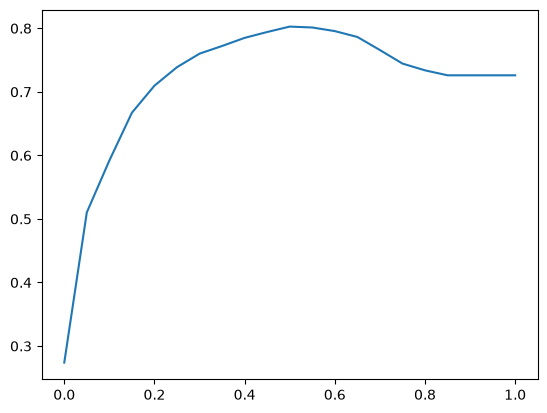

In [74]:
plt.plot(threshold, scores)

In [75]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, y_pred >= 0.5)

0.8026969481902059

In [76]:
threshold = np.linspace(0, 1, 21)

scores = []

for t in threshold:
    score = accuracy_score(y_val, y_pred >= t)
    scores.append(score)
    print(f'with t= {t:.2f} the accuracy is: {score:.3f}')

with t= 0.00 the accuracy is: 0.274
with t= 0.05 the accuracy is: 0.510
with t= 0.10 the accuracy is: 0.592
with t= 0.15 the accuracy is: 0.667
with t= 0.20 the accuracy is: 0.710
with t= 0.25 the accuracy is: 0.739
with t= 0.30 the accuracy is: 0.760
with t= 0.35 the accuracy is: 0.772
with t= 0.40 the accuracy is: 0.785
with t= 0.45 the accuracy is: 0.794
with t= 0.50 the accuracy is: 0.803
with t= 0.55 the accuracy is: 0.801
with t= 0.60 the accuracy is: 0.796
with t= 0.65 the accuracy is: 0.786
with t= 0.70 the accuracy is: 0.766
with t= 0.75 the accuracy is: 0.744
with t= 0.80 the accuracy is: 0.734
with t= 0.85 the accuracy is: 0.726
with t= 0.90 the accuracy is: 0.726
with t= 0.95 the accuracy is: 0.726
with t= 1.00 the accuracy is: 0.726


In [77]:
(y_pred >= 1)

array([False, False, False, ..., False, False, False], shape=(1409,))

In [78]:
from collections import Counter

Counter(y_pred >= 1)

Counter({np.False_: 1409})

In [79]:
Counter(y_val)

Counter({np.int64(0): 1023, np.int64(1): 386})

In [80]:
actual_positive = y_val == 1
actual_negative = y_val == 0

In [81]:
t = 0.5
predict_positive = y_pred >= t
predict_negative = y_pred < t

In [82]:
TP = (actual_positive & predict_positive).sum()
TN = (actual_negative & predict_negative).sum()
FP = (actual_negative & predict_positive).sum()
FN = (actual_positive & predict_negative).sum()
TP, TN, FP, FN

(np.int64(210), np.int64(921), np.int64(102), np.int64(176))

In [83]:
confusion_matrix = np.array(
    [
        [TN, FP],
        [FN, TP]
    ]
)
confusion_matrix

array([[921, 102],
       [176, 210]])

In [84]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

In [85]:
p = TP / (TP + FP)
p

np.float64(0.6730769230769231)

In [86]:
r = TP / (TP + FN)
r

np.float64(0.5440414507772021)

In [87]:
tpr = TP / (TP + FN)
fpr = FP / (FP + TN)
tpr, fpr

(np.float64(0.5440414507772021), np.float64(0.09970674486803519))

In [88]:
scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = y_val == 1
    actual_negative = y_val == 0
    predict_positive = y_pred >= t
    predict_negative = y_pred < t
    TP = (actual_positive & predict_positive).sum()
    TN = (actual_negative & predict_negative).sum()
    FP = (actual_negative & predict_positive).sum()
    FN = (actual_positive & predict_negative).sum()

    scores.append((t, TP, FP, FN, TN))

In [89]:
from collections import Counter
len(thresholds)

101

In [90]:
columns = ['threshold', 'TP', 'FP', 'FN', 'TN']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores[::10]

,threshold,TP,FP,FN,TN
0,0.0,386,1023,0,0
10,0.1,366,555,20,468
20,0.2,333,356,53,667
30,0.3,284,236,102,787
40,0.4,249,166,137,857
50,0.5,210,102,176,921
60,0.6,151,53,235,970
70,0.7,76,20,310,1003
80,0.8,13,2,373,1021
90,0.9,0,0,386,1023


In [91]:
df_scores['tpr'] = df_scores.TP / (df_scores.TP + df_scores.FN)
df_scores['fpr'] = df_scores.FP / (df_scores.FP + df_scores.TN)

df_scores[::10]

,threshold,TP,FP,FN,TN,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,366,555,20,468,0.948187,0.542522
20,0.2,333,356,53,667,0.862694,0.347996
30,0.3,284,236,102,787,0.735751,0.230694
40,0.4,249,166,137,857,0.645078,0.162268
50,0.5,210,102,176,921,0.544041,0.099707
60,0.6,151,53,235,970,0.391192,0.051808
70,0.7,76,20,310,1003,0.196891,0.019550
80,0.8,13,2,373,1021,0.033679,0.001955
90,0.9,0,0,386,1023,0.000000,0.000000


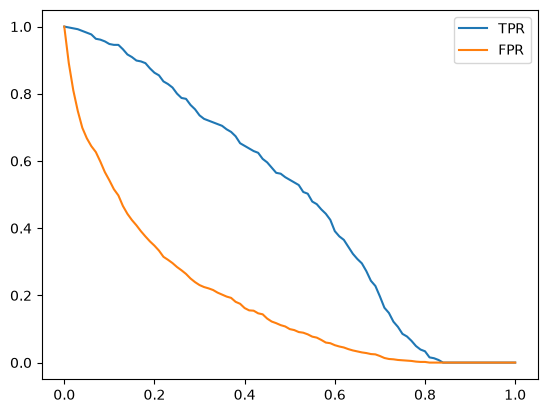

In [92]:
plt.plot(df_scores.threshold, df_scores.tpr, label = 'TPR')
plt.plot(df_scores.threshold, df_scores.fpr, label = 'FPR')
plt.legend()

In [93]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))

In [94]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [95]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = y_val == 1
        actual_negative = y_val == 0
        predict_positive = y_pred >= t
        predict_negative = y_pred < t
        TP = (actual_positive & predict_positive).sum()
        TN = (actual_negative & predict_negative).sum()
        FP = (actual_negative & predict_positive).sum()
        FN = (actual_positive & predict_negative).sum()

        scores.append((t, TP, FP, FN, TN))

    columns = ['threshold', 'TP', 'FP', 'FN', 'TN']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.TP / (df_scores.TP + df_scores.FN)
    df_scores['fpr'] = df_scores.FP / (df_scores.FP + df_scores.TN)

    return df_scores

In [96]:
df_rand = tpr_fpr_dataframe(y_val=y_val, y_pred=y_rand)

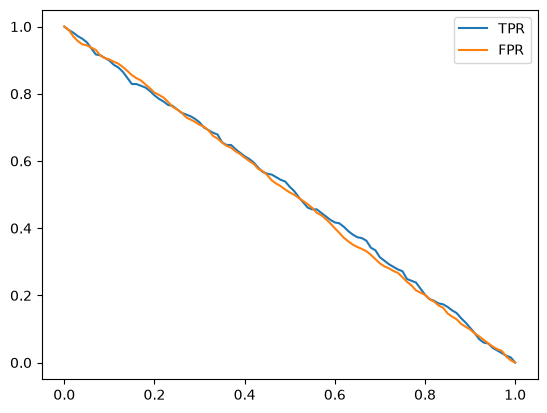

In [97]:
plt.plot(df_rand.threshold, df_rand.tpr, label = 'TPR')
plt.plot(df_rand.threshold, df_rand.fpr, label = 'FPR')
plt.legend()


In [98]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_pred)

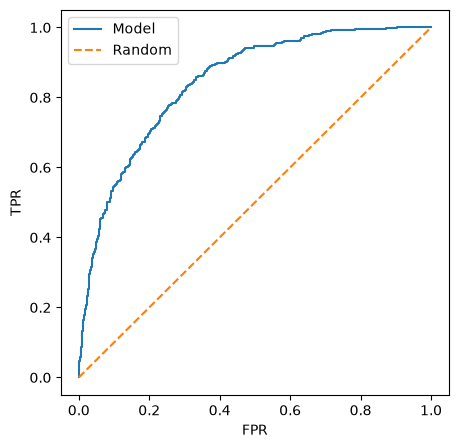

In [99]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

In [100]:
from sklearn.metrics import auc

auc(fpr, tpr)

0.8438150517374987

In [101]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_val, y_pred)

0.8438150517374987

In [146]:
def train(df_train, y_train, C=1):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=1000, solver='liblinear')
    model.fit(X_train, y_train)

    return dv, model


In [149]:
dv, model = train(df_train, y_train, C=0.1)

In [104]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [105]:
y_pred = predict(df_val, dv, model)

In [106]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

In [107]:
train_idx, val_idx = next(kfold.split(df_full_train))
len(train_idx), len(val_idx)

(5070, 564)

In [108]:
df_train = df_full_train.iloc[train_idx]
df_val = df_full_train.iloc[val_idx]

In [118]:
df_train.churn.values

array([0, 1, 0, ..., 1, 1, 0], shape=(5070,))

In [121]:
from tqdm.auto import  tqdm

In [150]:
scores = []

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):

    for train_idx, val_idx in tqdm(kfold.split(df_full_train)):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values


        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)

        scores.append(auc)

    print(f"C: {C}, {float(np.mean(scores)):.3f}, {float(np.std(scores)):.3f}")

  0%|          | 0/7 [00:00<?, ?it/s]

0it [00:00, ?it/s]

C: 0.001, 0.826, 0.016


0it [00:00, ?it/s]

C: 0.01, 0.833, 0.016


0it [00:00, ?it/s]

C: 0.1, 0.836, 0.015


0it [00:00, ?it/s]

C: 0.5, 0.838, 0.015


0it [00:00, ?it/s]

C: 1, 0.838, 0.014


0it [00:00, ?it/s]

C: 5, 0.839, 0.014


0it [00:00, ?it/s]

C: 10, 0.840, 0.014


In [123]:
scores

[0.8479080196555508,
 0.841042698019802,
 0.8557048652060528,
 0.8325323018681591,
 0.8266749379652605,
 0.8372294372294373,
 0.8412406382285901,
 0.8186195445920303,
 0.8451015266044167,
 0.8639037343282578]

In [128]:
float(np.mean(scores).round(3)), float(np.std(scores).round(3))

(0.841, 0.013)

In [ ]:
float(np.mean(scores).round(3)), float(np.std(scores).round(3))


In [154]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8579400803839363

In [9]:
C = 1

In [155]:
import pickle

In [158]:
output_file = f'model_C={C}.bin'
output_file

'model_C=10.bin'

In [160]:
with open(output_file, 'wb') as f_out:
    pickle.dump((dv, model), f_out)

## Load the model and use

In [1]:
import pickle

In [11]:
C = 10

In [12]:
input_file = f'model_C={C}.bin'
input_file

'model_C=10.bin'

In [14]:
with open(input_file, 'rb') as f_in:
    dv, model = pickle.load(f_in)

In [15]:
dv, model

(DictVectorizer(sparse=False),
 LogisticRegression(C=1, max_iter=1000, solver='liblinear'))

In [16]:
customer = {
    'gender': 'female',
    'seniorcitizen': 0,
    'partner': 'yes',
    'dependents': 'no',
    'phoneservice': 'no',
    'multiplelines': 'no_phone_service',
    'internetservice': 'dsl',
    'onlinesecurity': 'no',
    'onlinebackup': 'yes',
    'deviceprotection': 'no',
    'techsupport': 'no',
    'streamingtv': 'no',
    'streamingmovies': 'no',
    'contract': 'two_year',
    'paperlessbilling': 'yes',
    'paymentmethod': 'electronic_check',
    'tenure': 1,
    'monthlycharges': 29.85,
    'totalcharges': 29.85
}

In [18]:
X = dv.transform([customer])
X

array([[ 0.  ,  0.  ,  1.  ,  1.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ,
         0.  ,  1.  ,  0.  ,  0.  , 29.85,  0.  ,  1.  ,  0.  ,  0.  ,
         0.  ,  1.  ,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,  1.  ,
         0.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ,  0.  ,
         0.  ,  1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  , 29.85]])

In [19]:
model.predict_proba(X)

array([[0.61775868, 0.38224132]])